In [3]:
import pandas as pd
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data/mskcc/s7.csv')

imgs_folder = 'data/mskcc/images'


df.head()

,Unnamed: 0,isic_id,dermoscopic_type,img_l,img_a,img_b,img_ita,tag_id,type,anatomic_site,...,a_3,average_a,b_1,b_2,b_3,average_b,ita_1,ita_2,ita_3,average_ita
0,1,ISIC_6369402,NP-C,66.64,14.82,-5.97,-70.263331,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
1,2,ISIC_6052854,P-C,67.81,13.69,1.41,85.473392,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
2,3,ISIC_7075171,P-NC,64.19,17.55,1.44,84.205466,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
3,4,ISIC_5473699,NP-NC,63.70,18.36,-7.77,-60.440118,104514,normal-skin,upper back,...,14.0,14.33,11,11.0,10.0,10.66,53,52.0,56.0,53.66
4,5,ISIC_3868399,P-C,70.05,10.21,1.82,84.813301,105266,normal-skin,upper chest,...,9.0,8.66,12,12.0,11.0,11.66,48,50.0,49.0,49.00


Color in image (LAB):  [np.float64(146.36999999999998) np.float64(140.69) np.float64(129.39)]
Physical color (LAB):  [np.float64(160.64999999999998) np.float64(130.33) np.float64(150.0)]
Correction value (LAB):  [np.float64(1.0975609756097562) np.float64(0.9263629255810648)
 np.float64(1.159285879897983)]


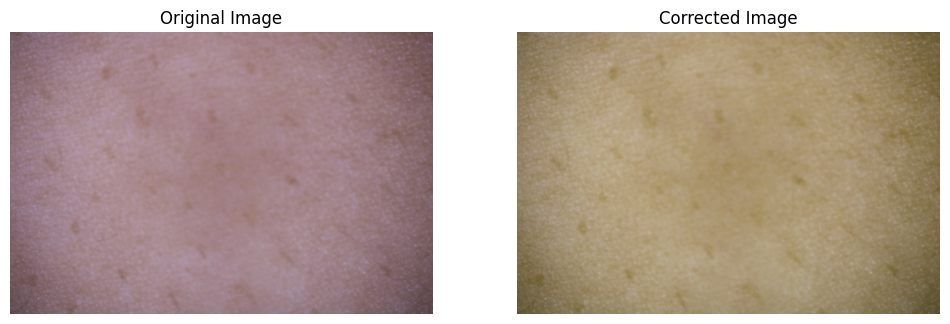

In [4]:
img_idx = 70

img_name = df.iloc[img_idx]['isic_id'] + '.jpg'
img_path = os.path.join(imgs_folder, img_name)
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

color_in_img = df.iloc[img_idx][['img_l', 'img_a', 'img_b']].values
color_physical = df.iloc[img_idx][['average_l', 'average_a', 'average_b']].values

# map to openCV LAB range
color_in_img[0] = color_in_img[0] * (255 / 100)
color_in_img[1] = color_in_img[1] + 128
color_in_img[2] = color_in_img[2] + 128

color_physical[0] = color_physical[0] * (255 / 100)
color_physical[1] = color_physical[1] + 128
color_physical[2] = color_physical[2] + 128

print("Color in image (LAB): ", color_in_img)
print("Physical color (LAB): ", color_physical)

# correction value
correction_value = color_physical / color_in_img
print("Correction value (LAB): ", correction_value)

# Apply correction to the image
img_lab = cv.cvtColor(img, cv.COLOR_RGB2LAB).astype(np.float32)
img_lab[:, :, 0] = img_lab[:, :, 0] * correction_value[0]
img_lab[:, :, 1] = img_lab[:, :, 1] * correction_value[1]
img_lab[:, :, 2] = img_lab[:, :, 2] * correction_value[2]
img_lab = np.clip(img_lab, 0, 255).astype(np.uint8)
img_corrected = cv.cvtColor(img_lab, cv.COLOR_LAB2RGB)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Corrected Image')
plt.imshow(img_corrected)
plt.axis('off')
plt.show()

In [5]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

metadata_csv = 'data/mskcc/metadata.csv'
ita_csv = 'data/mskcc/s7.csv'

metadata_df = pd.read_csv(metadata_csv)
ita_df = pd.read_csv(ita_csv)

combined_df = pd.merge(metadata_df, ita_df, on='isic_id')

print(combined_df.columns)
combined_df.head()

Index(['isic_id', 'attribution', 'copyright_license', 'age_approx',
       'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy',
       'dermoscopic_type_x', 'diagnosis_1', 'diagnosis_2',
       'diagnosis_confirm_type', 'fitzpatrick_skin_type', 'image_type',
       'lesion_id', 'melanocytic', 'patient_id', 'sex', 'Unnamed: 0',
       'dermoscopic_type_y', 'img_l', 'img_a', 'img_b', 'img_ita', 'tag_id',
       'type', 'anatomic_site', 'l_1', 'l_2', 'l_3', 'average_l', 'a_1', 'a_2',
       'a_3', 'average_a', 'b_1', 'b_2', 'b_3', 'average_b', 'ita_1', 'ita_2',
       'ita_3', 'average_ita'],
      dtype='object')


,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,dermoscopic_type_x,diagnosis_1,diagnosis_2,...,a_3,average_a,b_1,b_2,b_3,average_b,ita_1,ita_2,ita_3,average_ita
0,ISIC_0077599,Memorial Sloan Kettering Cancer Center,CC-BY,65.0,anterior torso,NaN,False,contact non-polarized,Benign,Benign - Other,...,10.0,11.33,23,23.0,26.0,24.00,8,8.0,6.0,7.33
1,ISIC_0086394,Memorial Sloan Kettering Cancer Center,CC-BY,75.0,upper extremity,NaN,False,contact non-polarized,Benign,Benign - Other,...,2.0,2.00,16,16.0,15.0,15.66,49,50.0,50.0,49.66
2,ISIC_0087198,Memorial Sloan Kettering Cancer Center,CC-BY,45.0,lower extremity,acral palms or soles,False,non-contact polarized,Benign,Benign - Other,...,6.0,10.00,19,20.0,20.0,19.66,-27,-24.0,-22.0,-24.33
3,ISIC_0091914,Memorial Sloan Kettering Cancer Center,CC-BY,70.0,anterior torso,NaN,False,NaN,Benign,Benign - Other,...,3.0,2.33,10,10.0,10.0,10.00,66,66.0,64.0,65.33
4,ISIC_0092255,Memorial Sloan Kettering Cancer Center,CC-BY,65.0,posterior torso,NaN,False,contact non-polarized,Benign,Benign - Other,...,7.0,6.66,24,20.0,24.0,22.66,32,27.0,28.0,29.00


## Compare White Balancing on MSKCC Dataset

In [6]:
import sys
sys.path.append('/home/marinbenc/Projects/nn_dermatoscopy_colorimetry')

from fp_dataset import FPDataset
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2 as cv
import pandas as pd
import os

# Load MSKCC dataset without white balancing
dataset_no_wb = FPDataset('mskcc', files=None, blur_amount=0, white_balance=False)

# Load MSKCC dataset with white balancing
dataset_wb = FPDataset('mskcc', files=None, blur_amount=0, white_balance=True)

# Load GT color data from s7.csv
s7_df = pd.read_csv('data/mskcc/s7.csv')

print(f"Dataset loaded: {len(dataset_no_wb)} images")
print(f"Fitzpatrick types distribution: {np.bincount([fp+1 for fp in dataset_no_wb.fps])}")

[FPDataset] Found all resized images for mskcc in mskcc_processed.
[FPDataset] 4879 processed files found for mskcc out of 4879 total entries.
[FPDataset] Found all resized images for mskcc in mskcc_processed.
[FPDataset] 4879 processed files found for mskcc out of 4879 total entries.
Dataset loaded: 4879 images
Fitzpatrick types distribution: [  0   0 789 950 794 783 813 750]


FP 1: 243 images with GT
FP 2: 258 images with GT
FP 3: 284 images with GT
FP 4: 307 images with GT
FP 5: 375 images with GT
FP 6: 371 images with GT


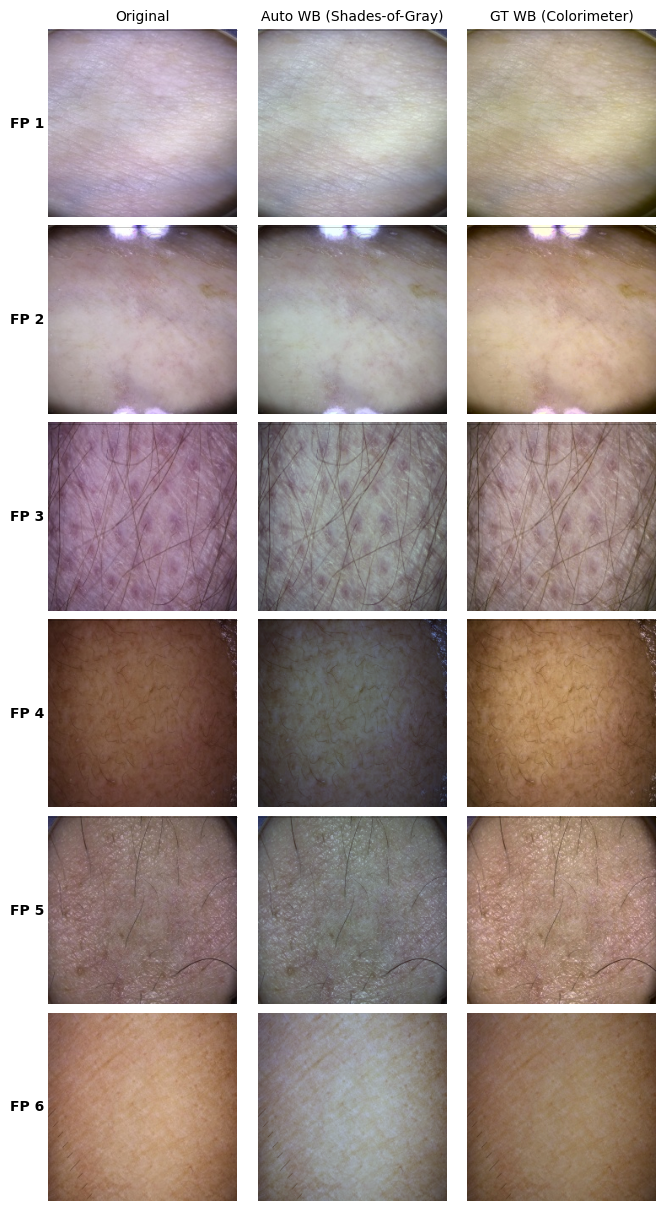

In [8]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

# --- settings for paper-quality figures ---
random.seed(42)
N_ROWS_PER_FP = 1
COL_TITLES = ["Original", "Auto WB (Shades-of-Gray)", "GT WB (Colorimeter)"]

# --- helper: inverse ImageNet normalization for torch tensors ---
def _tensor_to_rgb01(img_t):
    img = img_t.permute(1, 2, 0).detach().cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    return np.clip(img, 0, 1)

# --- helper: GT-based WB using s7 row ---
def _gt_wb_from_row(processed_path, gt_row):
    img_original = cv.imread(processed_path)
    img_original = cv.cvtColor(img_original, cv.COLOR_BGR2RGB)

    color_in_img = gt_row[["img_l", "img_a", "img_b"]].values[0].astype(np.float32).copy()
    color_physical = gt_row[["average_l", "average_a", "average_b"]].values[0].astype(np.float32).copy()

    color_in_img[0] = color_in_img[0] * (255.0 / 100.0)
    color_in_img[1] = color_in_img[1] + 128.0
    color_in_img[2] = color_in_img[2] + 128.0

    color_physical[0] = color_physical[0] * (255.0 / 100.0)
    color_physical[1] = color_physical[1] + 128.0
    color_physical[2] = color_physical[2] + 128.0

    correction_value = color_physical / np.maximum(color_in_img, 1e-6)

    img_lab = cv.cvtColor(img_original, cv.COLOR_RGB2LAB).astype(np.float32)
    img_lab[:, :, 0] = img_lab[:, :, 0] * correction_value[0]
    img_lab[:, :, 1] = img_lab[:, :, 1] * correction_value[1]
    img_lab[:, :, 2] = img_lab[:, :, 2] * correction_value[2]
    img_lab = np.clip(img_lab, 0, 255).astype(np.uint8)

    img_gt_wb = cv.cvtColor(img_lab, cv.COLOR_LAB2RGB)
    return img_gt_wb.astype(np.float32) / 255.0

# --- collect valid indices per FP (must exist in s7_df) ---
fp_valid_indices = {fp: [] for fp in range(1, 7)}
for idx, fp in enumerate(dataset_no_wb.fps):
    orig_file = dataset_no_wb.orig_files[idx]
    isic_id = os.path.basename(orig_file).replace(".jpg", "")
    if not s7_df[s7_df["isic_id"] == isic_id].empty:
        fp_valid_indices[int(fp)].append(idx)

for fp in range(1, 7):
    print(f"FP {fp}: {len(fp_valid_indices[fp])} images with GT")

# --- sample exactly N_ROWS_PER_FP per FP (or all if fewer) ---
samples_per_fp = {}
for fp in range(1, 7):
    pool = fp_valid_indices[fp]
    samples_per_fp[fp] = random.sample(pool, min(N_ROWS_PER_FP, len(pool)))

# --- one publication-ready figure: 6 blocks (FP1..FP6), 4 rows each, 3 columns ---
n_fp = 6
n_rows = sum(len(samples_per_fp[fp]) for fp in range(1, 7))
n_cols = 3

# size: keep cell size stable; scales with rows/cols (good for consistent spacing)
cell_w = 2.2
cell_h = 2.0
fig_w = cell_w * n_cols
fig_h = cell_h * max(1, n_rows)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(fig_w, fig_h),
    constrained_layout=True
)
if n_rows == 1:
    axes = np.array([axes])

# add column headers once
for j, t in enumerate(COL_TITLES):
    axes[0, j].set_title(t, fontsize=10)

row_cursor = 0
for fp in range(1, 7):
    idxs = samples_per_fp[fp]
    for i_fp, idx in enumerate(idxs):
        orig_file = dataset_no_wb.orig_files[idx]
        isic_id = os.path.basename(orig_file).replace(".jpg", "")
        gt_row = s7_df[s7_df["isic_id"] == isic_id]

        img_no_wb_t, _ = dataset_no_wb[idx]
        img_wb_t, _ = dataset_wb[idx]
        img_no_wb = _tensor_to_rgb01(img_no_wb_t)
        img_wb = _tensor_to_rgb01(img_wb_t)

        processed_path = dataset_no_wb.get_processed_path(orig_file)
        img_gt_wb = _gt_wb_from_row(processed_path, gt_row)

        axes[row_cursor, 0].imshow(img_no_wb)
        axes[row_cursor, 1].imshow(img_wb)
        axes[row_cursor, 2].imshow(img_gt_wb)

        for j in range(n_cols):
            axes[row_cursor, j].set_xticks([])
            axes[row_cursor, j].set_yticks([])
            axes[row_cursor, j].set_frame_on(False)

        # FP label on the left margin of the first column for each row
        axes[row_cursor, 0].text(
            -0.02, 0.5, f"FP {fp}",
            transform=axes[row_cursor, 0].transAxes,
            ha="right", va="center",
            fontsize=10, fontweight="bold"
        )

        row_cursor += 1

    # subtle separator line between FP blocks (except after last)
    if fp < 6 and row_cursor < n_rows:
        for j in range(n_cols):
            axes[row_cursor - 1, j].axhline(1.02, color="black", linewidth=0.6, alpha=0.25, clip_on=False)

# optional: rasterize for smaller vector PDFs if you save as PDF
# fig.savefig("wb_comparison_grid.pdf", bbox_inches="tight", dpi=300)

plt.show()

[FPDataset] Found all resized images for mskcc in mskcc_processed.
[LabDataset] 1838 processed files found for mskcc out of 1838 total entries.
LabDataset loaded: 1838 images
ITA statistics:
  Mean: 17.85
  Std: 34.70
  Min: -72.08
  Max: 80.16


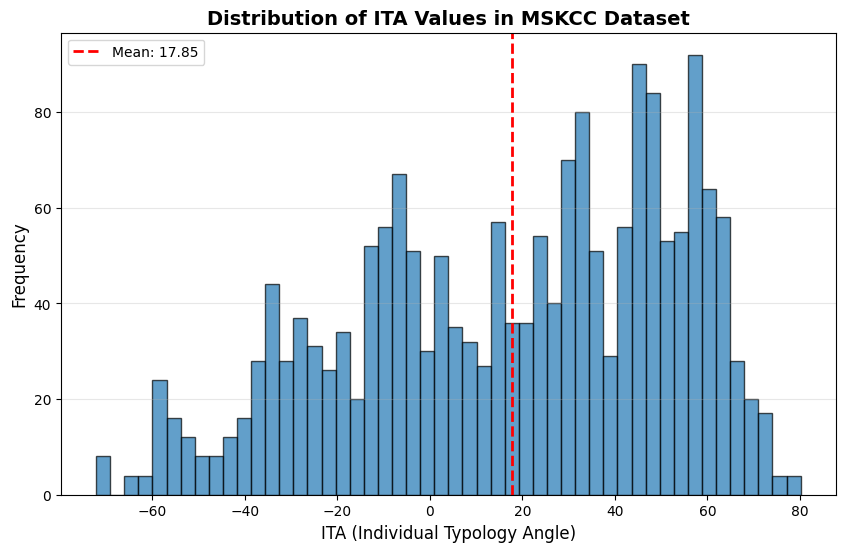

/tmp/ipykernel_3881666/3266273646.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ita_data, labels=fp_types)


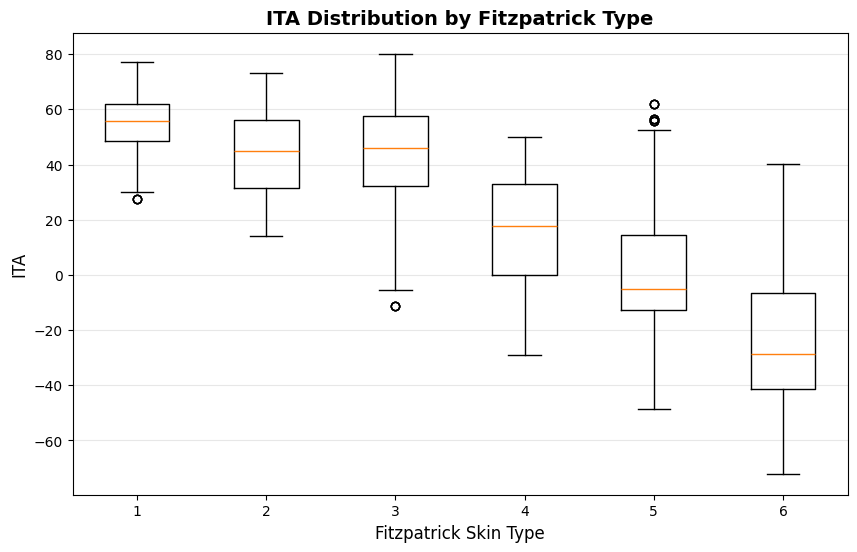

In [ ]:
# Load LabDataset and plot ITA distribution
from lab_dataset import LabDataset

# Load the dataset
lab_dataset = LabDataset('mskcc', files=None, blur_amount=0, white_balance=False)

print(f"LabDataset loaded: {len(lab_dataset)} images")

# Extract LAB values
lab_values = np.array(lab_dataset.lab_values)
l_values = lab_values[:, 0]
a_values = lab_values[:, 1]
b_values = lab_values[:, 2]

# Calculate ITA: ITA = arctan((L* - 50) / b*) * 180 / π
ita_values = np.arctan2((l_values - 50), b_values) * 180 / np.pi

print(f"ITA statistics:")
print(f"  Mean: {ita_values.mean():.2f}")
print(f"  Std: {ita_values.std():.2f}")
print(f"  Min: {ita_values.min():.2f}")
print(f"  Max: {ita_values.max():.2f}")

# Plot ITA distribution
plt.figure(figsize=(10, 6))
plt.hist(ita_values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('ITA (Individual Typology Angle)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of ITA Values in MSKCC Dataset', fontsize=14, fontweight='bold')
plt.axvline(ita_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {ita_values.mean():.2f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Plot ITA by Fitzpatrick type
plt.figure(figsize=(10, 6))
ita_by_fp = {fp: [] for fp in range(1, 7)}
for idx, fp in enumerate(lab_dataset.fps):
    ita_by_fp[fp].append(ita_values[idx])

fp_types = list(ita_by_fp.keys())
ita_data = [ita_by_fp[fp] for fp in fp_types]

plt.boxplot(ita_data, labels=fp_types)
plt.xlabel('Fitzpatrick Skin Type', fontsize=12)
plt.ylabel('ITA', fontsize=12)
plt.title('ITA Distribution by Fitzpatrick Type', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()